# Pretrained Carbon — log-likelihood loss on rice (whole-sequence vs. per-SNP)

Carbon is a decoder-only causal LM over DNA, so the natural loss is next-token
cross-entropy: for a 6-mer token at position $t$, $-\log P(\text{token}_t \mid \text{token}_{<t})$.
This notebook views that loss at two granularities, both produced by
[`pretrained_eval/eval.py`](eval.py) (one Carbon forward per window):

- **whole-sequence** — averaged over *every* DNA token in a window (how well Carbon
  models the rice sequence overall);
- **per-SNP** — restricted to the 6-mer tokens that contain a SNP/alt allele (how
  surprised Carbon is at the variant-bearing tokens specifically).

It reads the per-window CSV the eval writes to cluster scratch (the 90day-storage
migration — nothing here touches the home quota). Regenerate it with:

```bash
source env.sh
python pretrained_eval/eval.py --batch-size 16        # all ~53k variant windows
```

In [2]:
import sys, math
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().resolve().parents[0]))  # repo root (notebook lives in pretrained_eval/)
from pretrained_eval.paths import per_window_csv
from pretrained_eval.baselines import (uniform_kmer_nll, empirical_kmer_entropy,
                                       nats_per_token_to_bits_per_nt)
from pretrained_eval.loss import CARBON_KMER

# Which run to view — must match the eval's --model-path / --half-window.
MODEL_PATH  = "HuggingFaceBio/Carbon-500M"
HALF_WINDOW = 500
K = CARBON_KMER   # bases per token = 6 (Carbon DNA mode); used for bits/nt

CSV_PATH = per_window_csv(MODEL_PATH, HALF_WINDOW)   # or hard-code a Path here
print("reading:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
print(f"{len(df):,} windows  |  {int(df.seq_tokens.sum()):,} sequence tokens  "
      f"|  {int(df.snp_tokens.sum()):,} SNP tokens")
df.head()

reading: /90daydata/small_grains/andrew.dickson/pretrained_eval_out/per_window_Carbon-500M_hw500.csv
30,260 windows  |  5,053,420 sequence tokens  |  38,068 SNP tokens


,chrom,w_start,w_end,n_snps,seq_nll_sum,seq_tokens,seq_mean_nll,seq_ppl,snp_nll_sum,snp_tokens,snp_mean_nll,snp_ppl
0,1,13646,14646,1,1235.959351,167,7.400954,1637.546223,9.470390,1,9.470390,12969.948672
1,1,73691,74691,1,1239.728760,167,7.423526,1674.928083,7.725348,1,7.725348,2265.041755
2,1,75468,76468,1,1196.321045,167,7.163599,1291.550962,7.709615,1,7.709615,2229.683116
3,1,76351,77351,2,1263.791748,167,7.567615,1934.521441,18.448833,2,9.224417,10141.758993
4,1,76351,77351,1,1264.031860,167,7.569053,1937.304893,9.759291,1,9.759291,17314.346169


## Naive baselines

Two model-free reference points for the NLL, both in nats/6-mer:

- **uniform** over the 4096 DNA 6-mers = $\ln 4096 = 8.318$;
- **empirical 6-mer frequency** of the rice genome — a context-free frequency
  table, the honest bar a real model must beat. (Rice 6-mer composition is nearly
  flat, so it sits just below uniform.)

A model that beats the empirical baseline has learned context beyond composition.

In [3]:
from pretrained_eval.paths import scratch_base
FASTA = str(scratch_base() / "datasets" / "rice" / "Oryza_sativa.IRGSP-1.0.dna_sm.toplevel.fa")

UNIFORM = uniform_kmer_nll(K)                       # 8.318 nats/6-mer
emp = empirical_kmer_entropy(FASTA, k=K, n_windows=4000)
EMPIRICAL = emp["nats_per_kmer"]
print(f"uniform   : {UNIFORM:.4f} nats/6-mer   ({nats_per_token_to_bits_per_nt(UNIFORM, K):.4f} bits/nt)")
print(f"empirical : {EMPIRICAL:.4f} nats/6-mer   ({emp['bits_per_nt']:.4f} bits/nt)  "
      f"[{emp['n_kmers']:,} 6-mers, {emp['n_distinct']} distinct]")

uniform   : 8.3178 nats/6-mer   (2.0000 bits/nt)
empirical : 8.1824 nats/6-mer   (1.9674 bits/nt)  [663,996 6-mers, 4096 distinct]


## Aggregate metrics

The headline number is the **token-weighted** mean NLL (sum of per-token NLL over
all tokens / token count); perplexity is its exponential. The per-window means
plotted below are *un*weighted across windows, so they differ slightly — both are
shown for context.

In [4]:
def token_weighted(nll_sum, tokens):
    tok = int(df[tokens].sum())
    mean = float(df[nll_sum].sum()) / tok if tok else float("nan")
    return mean, (math.exp(mean) if tok else float("nan")), tok

for label, nll_sum, tokens in [("whole-sequence", "seq_nll_sum", "seq_tokens"),
                               ("per-SNP",        "snp_nll_sum", "snp_tokens")]:
    mean, ppl, tok = token_weighted(nll_sum, tokens)
    bpn = nats_per_token_to_bits_per_nt(mean, K)
    print(f"{label:15s}  mean NLL {mean:7.4f}   ppl {ppl:9.2f}   "
          f"{bpn:.4f} bits/nt   ({tok:,} tokens)")
print(f"\n(naive baselines: uniform {UNIFORM:.3f} / empirical {EMPIRICAL:.3f} nats-per-6-mer)")

whole-sequence   mean NLL  7.6305   ppl   2060.17   1.8348 bits/nt   (5,053,420 tokens)
per-SNP          mean NLL  8.1087   ppl   3323.28   1.9497 bits/nt   (38,068 tokens)

(naive baselines: uniform 8.318 / empirical 8.182 nats-per-6-mer)


## Whole-sequence loss distribution

One value per window, averaged over all its DNA tokens.

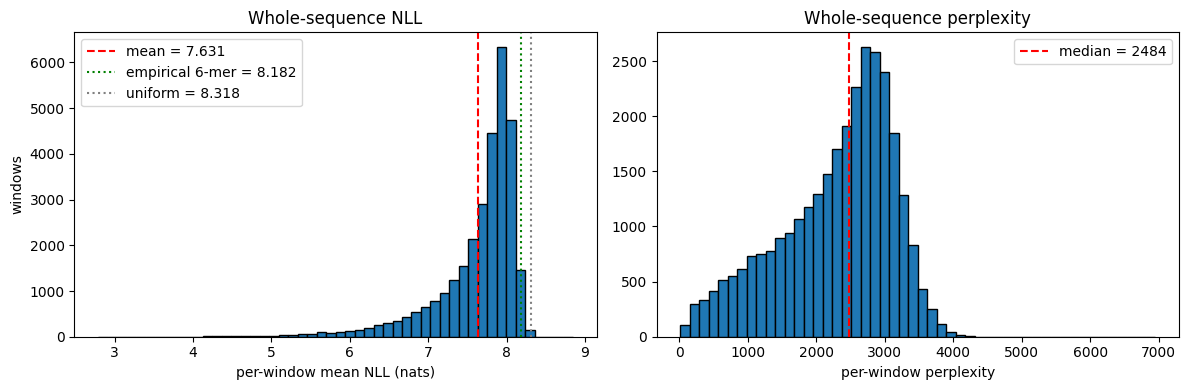

In [5]:
seq = df["seq_mean_nll"].dropna()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(seq, bins=50, edgecolor="black")
ax[0].axvline(seq.mean(), color="red", ls="--", label=f"mean = {seq.mean():.3f}")
ax[0].axvline(EMPIRICAL, color="green", ls=":", label=f"empirical 6-mer = {EMPIRICAL:.3f}")
ax[0].axvline(UNIFORM, color="grey", ls=":", label=f"uniform = {UNIFORM:.3f}")
ax[0].set(xlabel="per-window mean NLL (nats)", ylabel="windows",
          title="Whole-sequence NLL")
ax[0].legend()

ax[1].hist(np.exp(seq), bins=50, edgecolor="black")
ax[1].axvline(np.exp(seq).median(), color="red", ls="--",
              label=f"median = {np.exp(seq).median():.0f}")
ax[1].set(xlabel="per-window perplexity", title="Whole-sequence perplexity")
ax[1].legend()
fig.tight_layout()

## Per-SNP loss distribution

Restricted to windows that have at least one in-range SNP token (a SNP truncated
past `--max-length` contributes none). Each value is the mean NLL over that
window's SNP tokens.

In [ ]:
snp = df.loc[df["snp_tokens"] > 0, "snp_mean_nll"].dropna()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(snp, bins=50, edgecolor="black", color="darkorange")
ax[0].axvline(snp.mean(), color="red", ls="--", label=f"mean = {snp.mean():.3f}")
ax[0].axvline(EMPIRICAL, color="green", ls=":", label=f"empirical 6-mer = {EMPIRICAL:.3f}")
ax[0].axvline(UNIFORM, color="grey", ls=":", label=f"uniform = {UNIFORM:.3f}")
ax[0].set(xlabel="per-window mean SNP NLL (nats)", ylabel="windows",
          title="Per-SNP NLL")
ax[0].legend()

ax[1].hist(np.exp(snp), bins=50, edgecolor="black", color="darkorange")
ax[1].axvline(np.exp(snp).median(), color="red", ls="--",
              label=f"median = {np.exp(snp).median():.0f}")
ax[1].set(xlabel="per-window SNP perplexity", title="Per-SNP perplexity")
ax[1].legend()
fig.tight_layout()

## Whole-sequence vs. per-SNP, side by side

SNP-containing 6-mers carry the alt allele, so they are typically *more* surprising
to a model pretrained on (mostly reference) genomes — the per-SNP distribution
should sit to the right of the whole-sequence one.

In [ ]:
both = df.loc[df["snp_tokens"] > 0]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(both["seq_mean_nll"], bins=50, alpha=0.6, label="whole-sequence", edgecolor="black")
ax.hist(both["snp_mean_nll"], bins=50, alpha=0.6, label="per-SNP", color="darkorange",
        edgecolor="black")
ax.axvline(both["seq_mean_nll"].mean(), color="C0", ls="--")
ax.axvline(both["snp_mean_nll"].mean(), color="darkorange", ls="--")
ax.axvline(EMPIRICAL, color="green", ls=":", label=f"empirical 6-mer = {EMPIRICAL:.3f}")
ax.axvline(UNIFORM, color="grey", ls=":", label=f"uniform = {UNIFORM:.3f}")
ax.set(xlabel="mean NLL (nats)", ylabel="windows",
       title="Per-window loss: whole-sequence vs. SNP tokens")
ax.legend()
fig.tight_layout()

delta = (both["snp_mean_nll"] - both["seq_mean_nll"])
print(f"SNP tokens are higher-loss than their window in "
      f"{(delta > 0).mean()*100:.1f}% of windows  "
      f"(mean delta = {delta.mean():+.3f} nats)")

## Per-chromosome summary

Token-weighted mean NLL by chromosome — a quick check for assembly regions where
Carbon is systematically more/less confident.

In [ ]:
def chrom_tw(g):
    return pd.Series({
        "windows": len(g),
        "seq_nll": g.seq_nll_sum.sum() / g.seq_tokens.sum(),
        "snp_nll": g.snp_nll_sum.sum() / max(g.snp_tokens.sum(), 1),
        "snp_tokens": int(g.snp_tokens.sum()),
    })

by_chrom = df.groupby("chrom").apply(chrom_tw)
display(by_chrom.round(3))

ax = by_chrom[["seq_nll", "snp_nll"]].plot.bar(figsize=(10, 4))
ax.set(xlabel="chromosome", ylabel="token-weighted mean NLL",
       title="Per-chromosome loss")
ax.legend(["whole-sequence", "per-SNP"])
plt.tight_layout()